<Axes: >

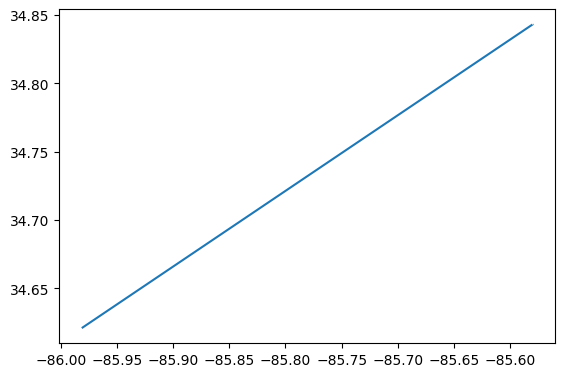

In [1]:
import geopandas as gpd

# GROUNDTRUTH FILES, UPDATE IF NEEDED
shp_path = "/mnt/data2/le000415/Prof_Ding_Lab/OU_Datasets_0302/tornados_shp/tor10/nws_dat_damage_paths.shp"

gdf = gpd.read_file(shp_path)

# print(gdf.head())
gdf.plot()

In [2]:
gdf = gpd.read_file(shp_path)
print(gdf.geometry.geom_type.value_counts())

LineString    1
Name: count, dtype: int64


In [3]:
import tifffile as tiff
import matplotlib.pyplot as plt

# MAKE CHANGES TO THE PATH TO THE TORNADO FILE IF NEEDED
tor_path = "/mnt/data2/le000415/Prof_Ding_Lab/OU_Datasets_0302/TOR10_BEST_AFTER_win10d.tif"
tor_img = tiff.imread(tor_path)

In [4]:
print(tor_img.shape)
print(tor_img.dtype)

import numpy as np
print("min:", np.nanmin(tor_img))
print("max:", np.nanmax(tor_img))

(1301, 2735, 6)
float32
min: -0.0081875
max: 1.6022125


In [5]:
for c in range(6):
    ch = tor_img[:,:,c]
    print(
        f"Band {c}:",
        "min =", np.nanmin(ch),
        "max =", np.nanmax(ch),
        "mean =", np.nanmean(ch),
        "std =", np.nanstd(ch)
    )

Band 0: min = 0.0062225 max = 1.6022125 mean = 0.02919382 std = 0.015208987
Band 1: min = 0.01307 max = 0.6322325 mean = 0.054160185 std = 0.017054956
Band 2: min = 0.0101275 max = 1.6022125 mean = 0.044727147 std = 0.023811825
Band 3: min = 0.012685 max = 0.775095 mean = 0.33545846 std = 0.070437625
Band 4: min = -0.0047225 max = 1.6022125 mean = 0.1760899 std = 0.0535126
Band 5: min = -0.0081875 max = 1.6022125 mean = 0.08114083 std = 0.0398121


In [6]:
flat = tor_img.reshape(-1, 6)
flat = flat[np.all(np.isfinite(flat), axis=1)]  # remove NaN rows

print("TOR10_BEST_BEFORE_win25d")
corr = np.corrcoef(flat.T)
print(corr)

TOR10_BEST_BEFORE_win25d
[[ 1.          0.82987199  0.82674455 -0.13154273  0.59619318  0.70447436]
 [ 0.82987199  1.          0.94836323 -0.003732    0.7703923   0.85320642]
 [ 0.82674455  0.94836323  1.         -0.16637179  0.7742202   0.902911  ]
 [-0.13154273 -0.003732   -0.16637179  1.          0.29065718  0.01167919]
 [ 0.59619318  0.7703923   0.7742202   0.29065718  1.          0.92977141]
 [ 0.70447436  0.85320642  0.902911    0.01167919  0.92977141  1.        ]]


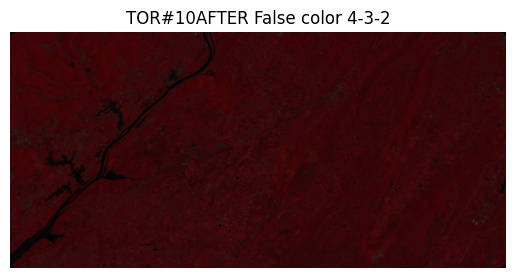

In [7]:
rgb = tor_img[:, :, [3,2,1]]  # bands 4-3-2

rgb = np.nan_to_num(rgb)

rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.imshow(rgb)
plt.title("TOR#10AFTER False color 4-3-2")
plt.axis("off")
plt.show()

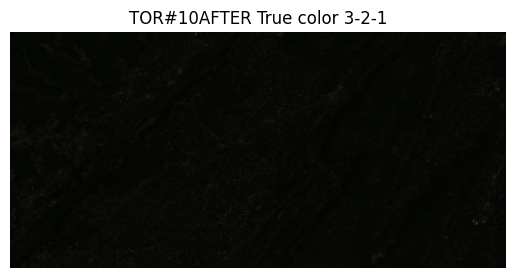

In [8]:
rgb = tor_img[:, :, [2,1,0]]  # bands 3-2-1

rgb = np.nan_to_num(rgb)

rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.imshow(rgb)
plt.title("TOR#10AFTER True color 3-2-1")
plt.axis("off")
plt.show()

Valid pixel percentage: 0.9993741279033004


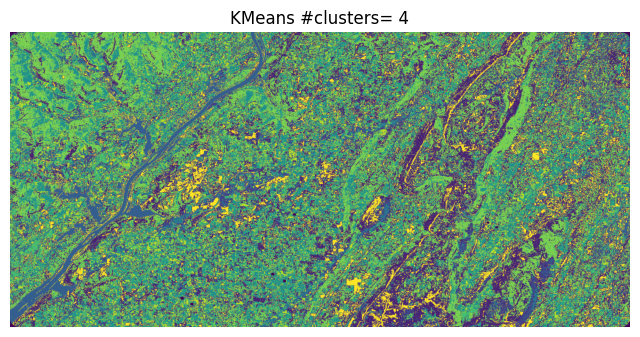

In [11]:
# CLUSTERING USING K-MEANS
import numpy as np

# create valid pixel mask
valid = np.isfinite(tor_img).all(axis=2)

print("Valid pixel percentage:", valid.mean())

from sklearn.cluster import KMeans

X = tor_img[valid]   # shape (N_valid, 6)
kmeans = KMeans(n_clusters=10, random_state=0, n_init="auto")
labels = kmeans.fit_predict(X)

cluster_map = np.full(valid.shape, -1, dtype=int)
cluster_map[valid] = labels

plt.figure(figsize=(8,6))
plt.imshow(cluster_map)
plt.title("KMeans #clusters= 4")
plt.axis("off")
plt.show()

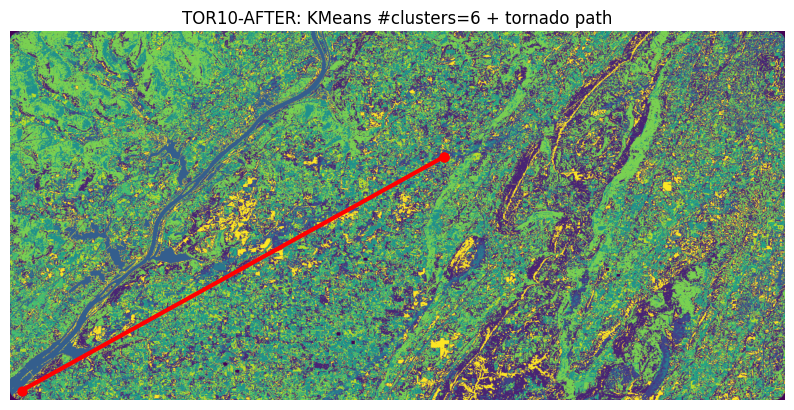

In [12]:
import rasterio

with rasterio.open(tor_path) as src:
    transform = src.transform

#######################################
from rasterio.transform import rowcol

rows = []
cols = []

# FOR DOTS TOR PATH
# for geom in gdf.geometry:
#     lon = geom.x
#     lat = geom.y

#     r, c = rowcol(transform, lon, lat)

#     rows.append(r)
#     cols.append(c)


# FOR LINESTRING TOR PATH
for geom in gdf.geometry:
    # get coordinates along the line
    for lon, lat in geom.coords:

        r, c = rowcol(transform, lon, lat)

        rows.append(r)
        cols.append(c)

################################################
plt.figure(figsize=(10,7))

plt.imshow(cluster_map)
# For dots
plt.scatter(cols, rows, c="red", s=40)
# For linestring
plt.plot(cols, rows, color="red", linewidth=3)
plt.title("TOR10-AFTER: KMeans #clusters=6 + tornado path")
plt.axis("off")

plt.show()